# Comprehensive Exploratory Data Analysis (EDA)
This notebook provides a deep-dive exploration of all 17 NCES ELS:2002 summary tables. 
The goal is to systematically map every dimension (demographics, achievement, psychology, institutional context) 
to the choice of a STEM major to identify the most robust predictors and potential confounders for causal analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
project_root = Path('.').resolve().parent
df = pd.read_csv(project_root / 'outputs' / 'tables' / 'nces_postsecondary_tidy.csv', dtype={'table_id': str})
df['section_label'] = df['section_label'].fillna('Main')
print(f'Loaded {len(df)} rows across {df['table_id'].nunique()} tables.')

Loaded 1314 rows across 17 tables.


In [ ]:
def plot_characteristic_by_major(table_ids, title, height=6):
    """Plots tables where characteristics are rows and STEM/Non-STEM are columns."""
    plot_df = df[df['table_id'].isin(table_ids)].copy()
    
    # Normalize STEM/Non-STEM categorization
    def get_major_cat(row):
        group = str(row['column_group']).lower()
        label = str(row['column_label']).lower()
        if 'non-stem' in group or 'non-stem' in label:
            return 'Non-STEM'
        if 'stem' in group or 'stem' in label:
            return 'STEM'
        return 'Other'
    
    plot_df['major_cat'] = plot_df.apply(get_major_cat, axis=1)
    
    # Filter for rows that represent the aggregate STEM/Non-STEM category
    # Case 1: table 1/2/4/10 -> column_label is 'Total' (column_group has STEM/Non-STEM)
    # Case 2: table 15/16/17 -> column_label is 'STEM major in 2006' (column_group is empty)
    mask = (plot_df['column_label'] == 'Total') | \
           (plot_df['column_label'].str.contains('STEM major', case=False, na=False))
    
    plot_df = plot_df[mask & (plot_df['major_cat'] != 'Other')]
    
    if plot_df.empty:
        print(f"No valid rows found for tables: {table_ids}")
        return

    g = sns.catplot(
        data=plot_df, kind='bar', x='estimate', y='row_label', hue='major_cat',
        col='table_id', col_wrap=2, sharey=False, height=height, aspect=1.5,
        hue_order=['STEM', 'Non-STEM']
    )
    g.fig.suptitle(title, y=1.02, fontsize=16)
    plt.show()

def plot_major_by_characteristic(table_ids, title, height=6):
    """Plots tables where Major is the row (Total, STEM, Non-STEM) and categories are columns."""
    plot_df = df[df['table_id'].isin(table_ids)].copy()
    
    if plot_df.empty:
        print(f"No valid rows found for tables: {table_ids}")
        return

    g = sns.catplot(
        data=plot_df, kind='bar', x='estimate', y='column_label', hue='row_label',
        col='table_id', col_wrap=2, sharey=False, height=height, aspect=1.5
    )
    g.fig.suptitle(title, y=1.02, fontsize=16)
    plt.show()

## Theme 1: Academic Achievement & Preparation
Tables: 1 (Math Quartile), 2 (Math/Science Courses), 4 (Expectations + Courses), 10 (Declared Major + Courses).

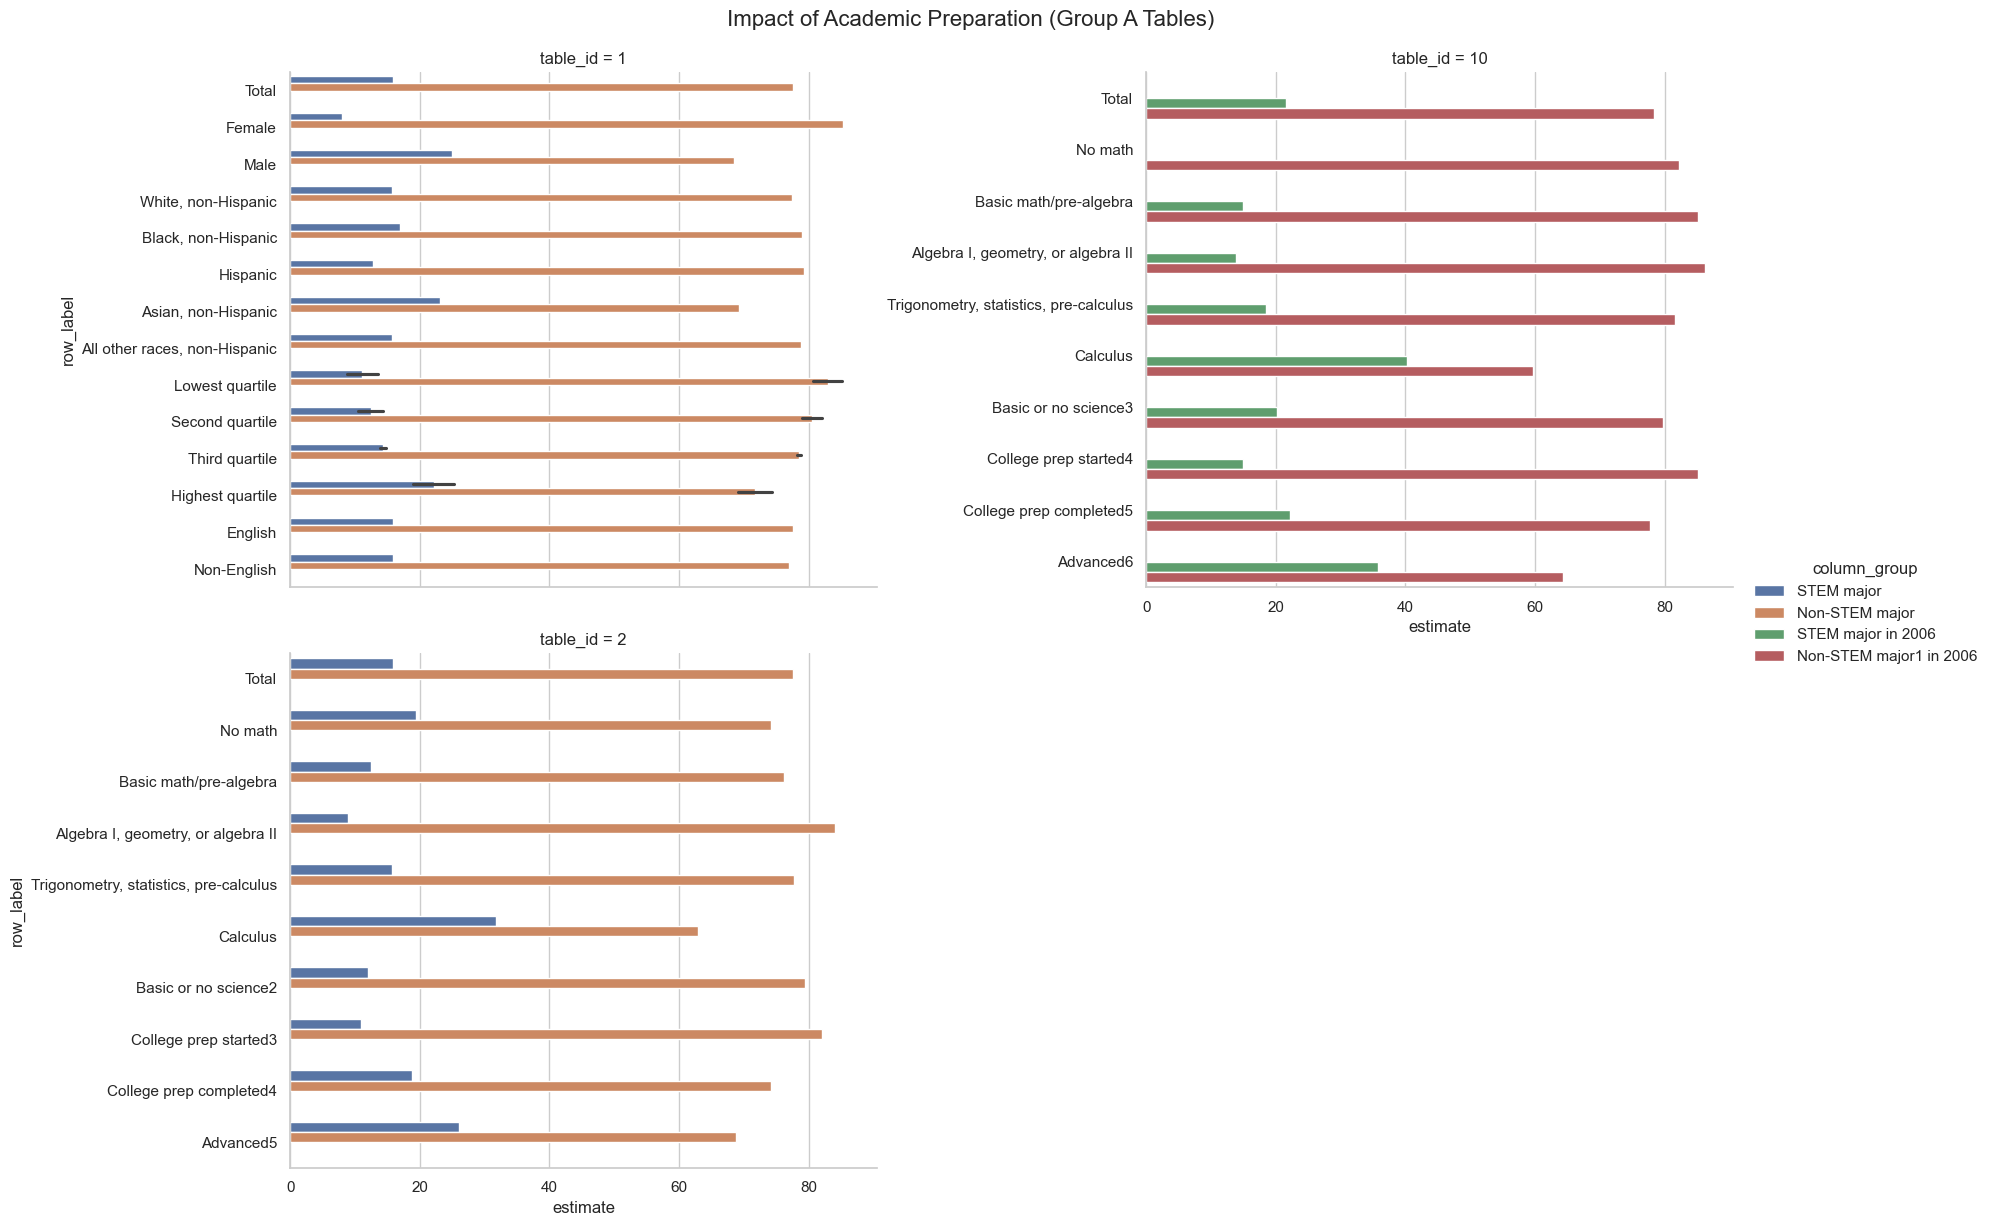

In [3]:
# Theme 1: Academic Preparation (Group A)
plot_characteristic_by_major(['1', '2', '4', '10'], 'Impact of Academic Preparation (Group A Tables)')

## Theme 2: Math Enjoyment & Self-Efficacy
Tables: 15 (Enjoyment), 16 (Confidence on Tests), 17 (Confidence on Assignments).

In [4]:
# Theme 2: Psychosocial (Group A)
plot_characteristic_by_major(['15', '16', '17'], 'Psychosocial Factors: Enjoyment and Self-Efficacy (Group A Tables)')

No valid rows found for Group A tables: ['15', '16', '17']


## Theme 3: Institutional Context & Intensity
Tables: 3 (Expectations), 6 (Level), 7 (Intensity), 11-14 (Sector).

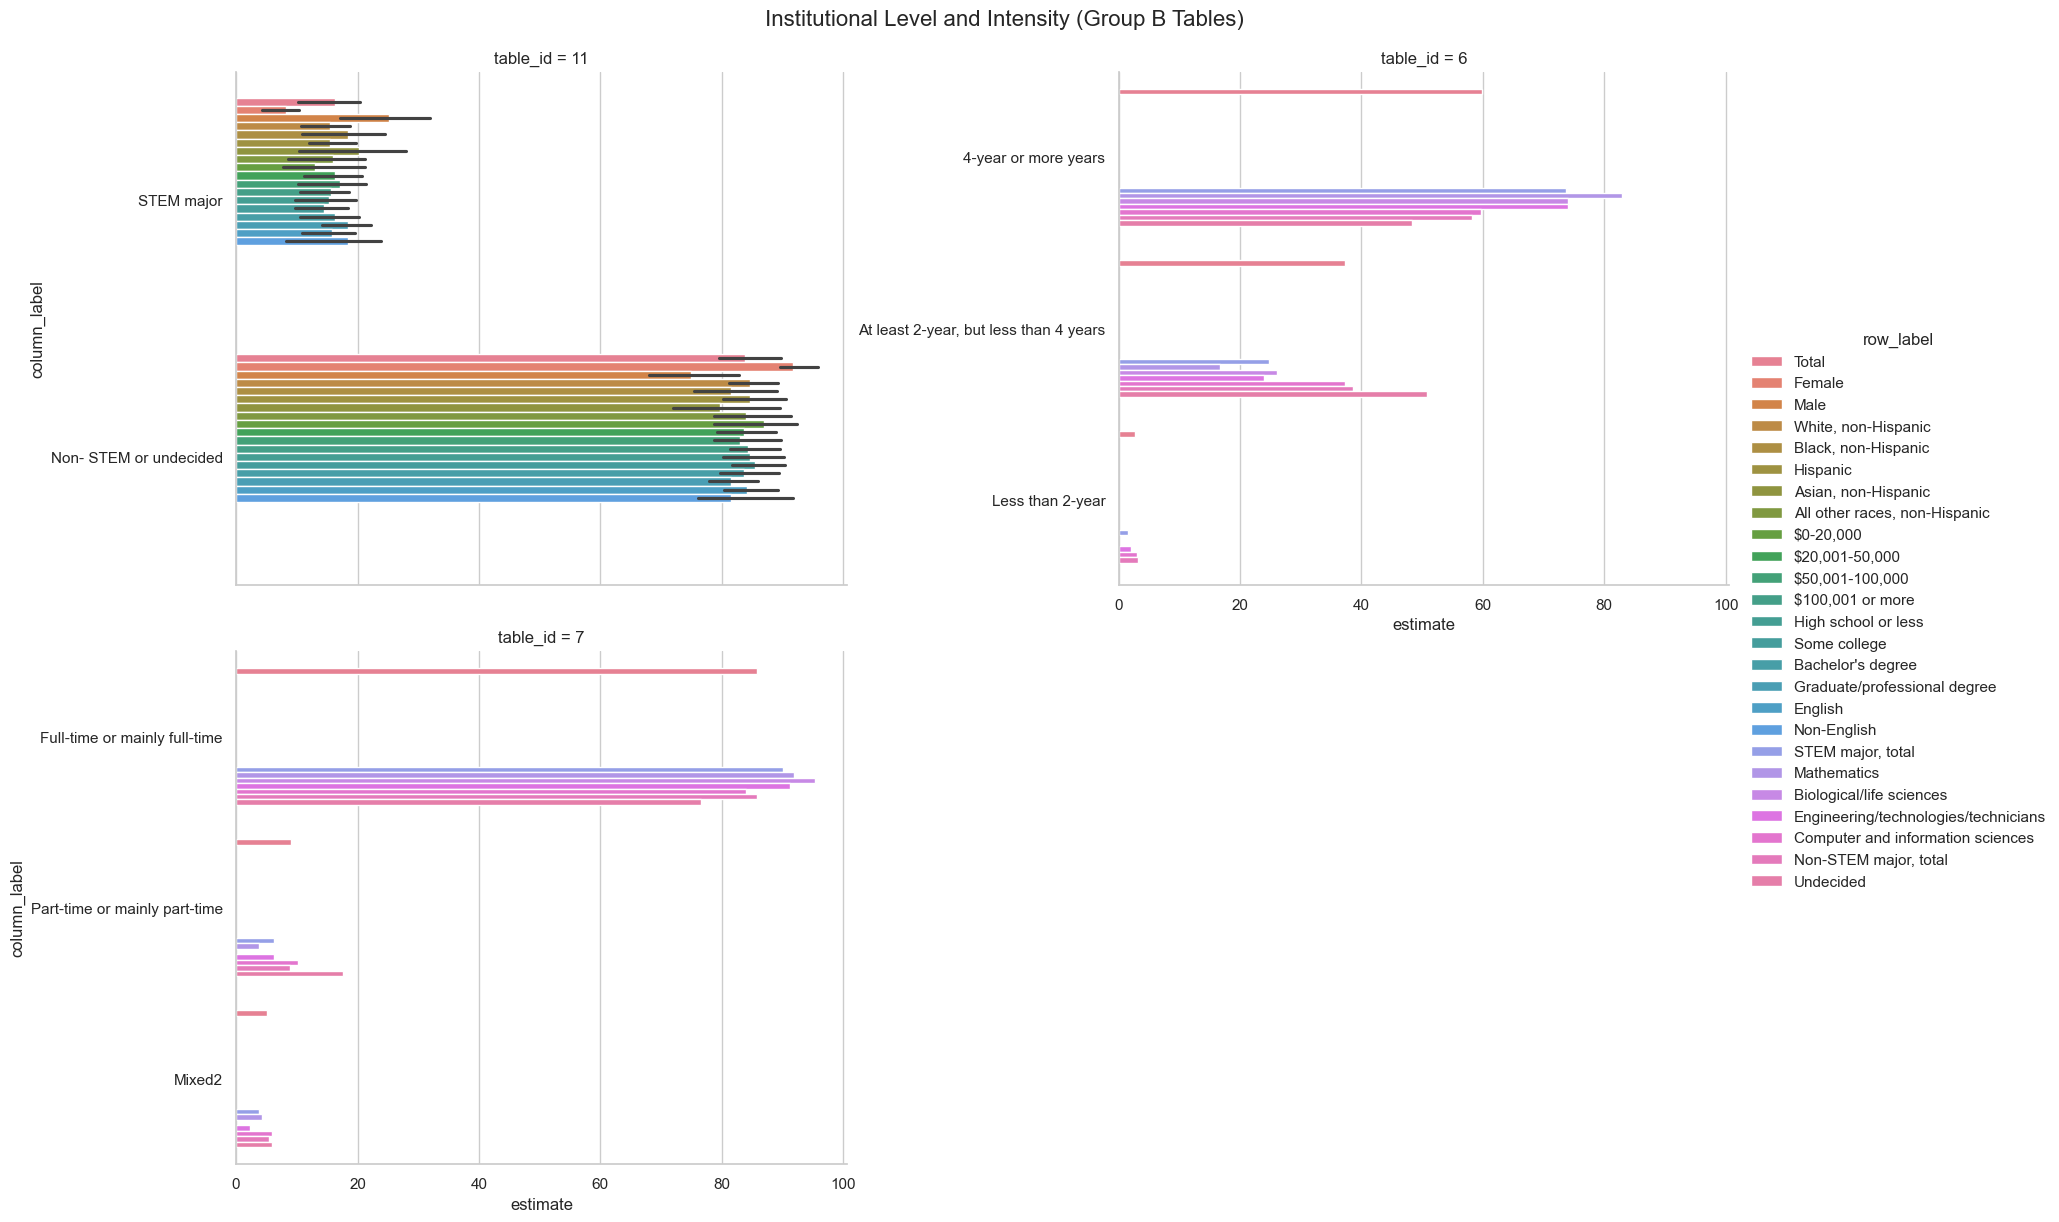

In [5]:
# Theme 3: Institutional (Group B)
plot_major_by_characteristic(['6', '7', '11'], 'Institutional Level and Intensity (Group B Tables)')

## Summary of STEM Probability across Dimensions
Let's rank the factors by their observed STEM 'Premium'.

In [ ]:
# Refined Summary: Top STEM Predictors
# We need to be careful with the diverse table structures.

# 1. Identify rows that represent a 'STEM major' probability
def is_stem_row(row):
    group = str(row['column_group'])
    label = str(row['column_label'])
    row_text = str(row['row_label'])
    
    # Exclude Non-STEM explicitly
    if any('non-stem' in s.lower() for s in [group, label, row_text]):
        return False
        
    # Check for STEM keywords in column or row
    if 'stem major' in group.lower() or 'stem major' in label.lower():
        # For these tables, we usually want the 'Total' or the specific major column
        # If it's a breakdown table (Table 1), we want column_label == 'Total'
        if 'Total' in label or label == 'STEM major in 2006':
            return True
    
    # For Group B tables where STEM is in the row label
    if 'stem major' in row_text.lower() and row['table_id'] in ['6', '7', '11']:
        return True
        
    return False

df_copy = df.copy()
df_copy['is_stem_prob'] = df_copy.apply(is_stem_row, axis=1)
summary = df_copy[df_copy['is_stem_prob']].copy()

# Focus on Group A style: Probability of STEM given Characteristic
group_a_ids = ['1', '2', '3', '4', '8', '9', '10', '15', '16', '17']
rank_df = summary[summary['table_id'].isin(group_a_ids)].copy()

# Clean up row labels for better readability (remove footnotes like Calculus2 -> Calculus)
rank_df['row_label_clean'] = rank_df['row_label'].str.replace(r'\d+$', '', regex=True)

rank_df = rank_df[['table_id', 'section_label', 'row_label_clean', 'estimate']].sort_values('estimate', ascending=False)

print('Top 25 Factors Correlated with Higher STEM Probability:')
print(rank_df.head(25).to_string(index=False))

print('\nBottom 20 Factors (Lowest STEM Probability):')
print(rank_df.tail(20).to_string(index=False))